Plotting Farasis SOH:   0%|          | 0/3 [00:00<?, ?it/s]

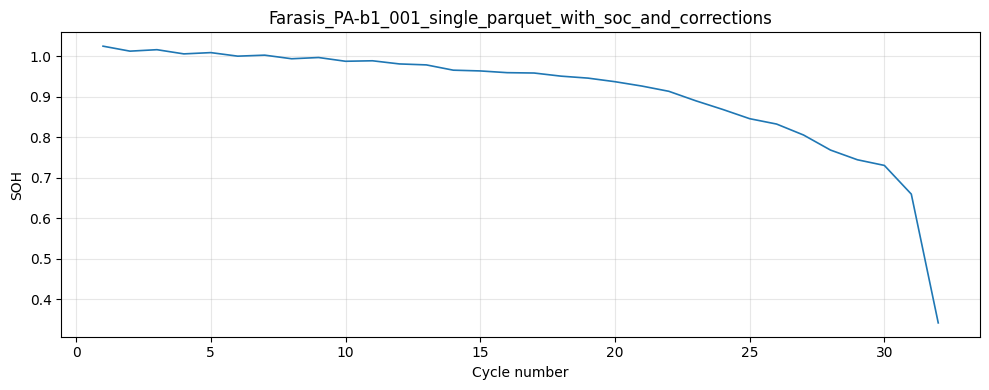

Plotting Farasis SOH:  33%|███▎      | 1/3 [00:16<00:32, 16.13s/it]

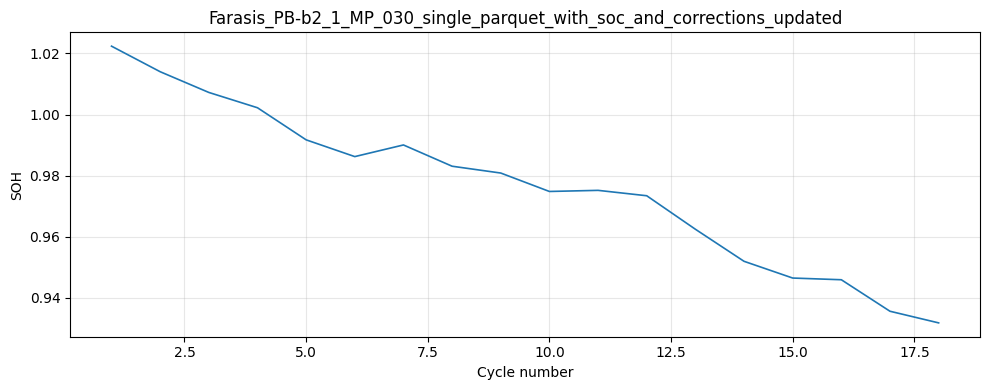

Plotting Farasis SOH:  67%|██████▋   | 2/3 [00:25<00:12, 12.12s/it]

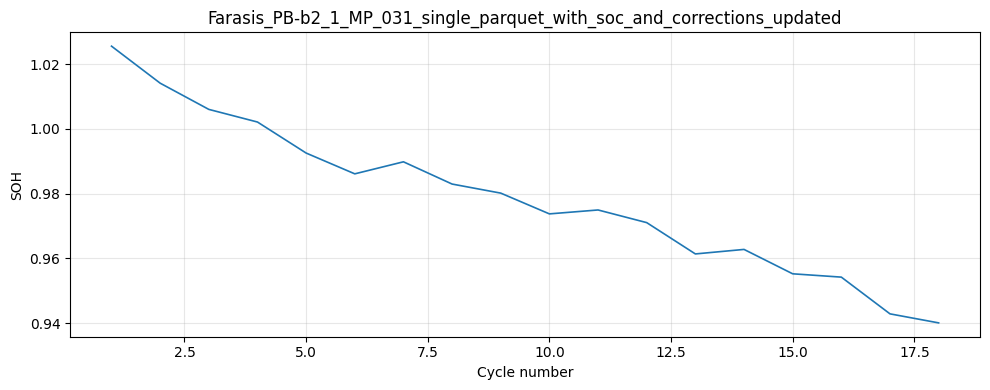

Plotting Farasis SOH: 100%|██████████| 3/3 [00:29<00:00,  9.70s/it]

Done.
pkl_files: 3
ok_cells: 3


,cell_id,pkl,n_cycles,nominal_capacity_in_Ah,soc_span,soh_first,soh_last,soh_min,status
0,Farasis_PA-b1_001_single_parquet_with_soc_and_...,E:\第三人生\HKUSTgz\BatteryLife\dataset\processed\...,32,73.0,1.0,1.025192,0.341268,0.341268,ok
1,Farasis_PB-b2_1_MP_030_single_parquet_with_soc...,E:\第三人生\HKUSTgz\BatteryLife\dataset\processed\...,18,76.0,1.0,1.022377,0.931759,0.931759,ok
2,Farasis_PB-b2_1_MP_031_single_parquet_with_soc...,E:\第三人生\HKUSTgz\BatteryLife\dataset\processed\...,18,76.0,1.0,1.025533,0.940123,0.940123,ok


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'dataset').exists() and (p / 'check_data_scripts').exists():
            return p
    raise FileNotFoundError('Cannot locate project root containing dataset/ and check_data_scripts/')

def _get_field(obj, key, default=None):
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

def _safe_soc_span(raw_soc_interval):
    if isinstance(raw_soc_interval, (list, tuple)) and len(raw_soc_interval) >= 2:
        try:
            span = float(raw_soc_interval[1]) - float(raw_soc_interval[0])
            if np.isfinite(span) and abs(span) > 1e-12:
                return abs(span)
        except Exception:
            pass
    return 1.0

def _compute_cycle_soh(cycle, nominal_capacity, soc_span):
    current = np.asarray(_get_field(cycle, 'current_in_A', []), dtype=float)
    discharge = np.asarray(_get_field(cycle, 'discharge_capacity_in_Ah', []), dtype=float)
    n = min(len(current), len(discharge))
    if n == 0:
        return np.nan
    current = current[:n]
    discharge = discharge[:n]

    mask = np.isfinite(current) & np.isfinite(discharge)
    if not np.any(mask):
        return np.nan
    current = current[mask]
    discharge = discharge[mask]

    # Prefer discharge period points; fallback to full curve if no negative current exists.
    dmask = current < 0
    if np.any(dmask):
        qd = float(np.nanmax(discharge[dmask]))
    else:
        qd = float(np.nanmax(discharge))

    if not np.isfinite(nominal_capacity) or nominal_capacity <= 0:
        return np.nan
    return qd / float(nominal_capacity) / float(soc_span)

repo_root = _find_repo_root(Path.cwd())
pkl_dir = repo_root / 'dataset' / 'processed' / 'Farasis'

# 遍历 Farasis 下全部 pkl
pkl_files = sorted([p for p in pkl_dir.glob('*.pkl') if p.stem.startswith('Farasis_')])
if len(pkl_files) == 0:
    raise FileNotFoundError(f'No Farasis pkl files found under: {pkl_dir}')

summary_rows = []

for pkl_path in tqdm(pkl_files, desc='Plotting Farasis SOH'):
    with pkl_path.open('rb') as f:
        obj = pickle.load(f)

    cycle_data = _get_field(obj, 'cycle_data', [])
    nominal_capacity = float(_get_field(obj, 'nominal_capacity_in_Ah', np.nan))
    cell_id = str(_get_field(obj, 'cell_id', pkl_path.stem))
    soc_span = _safe_soc_span(_get_field(obj, 'SOC_interval', [0, 1]))

    if len(cycle_data) == 0:
        summary_rows.append({
            'cell_id': cell_id,
            'pkl': str(pkl_path),
            'n_cycles': 0,
            'nominal_capacity_in_Ah': nominal_capacity,
            'soc_span': soc_span,
            'soh_first': np.nan,
            'soh_last': np.nan,
            'soh_min': np.nan,
            'status': 'empty_cycle_data'
        })
        continue

    cycles = []
    soh_values = []
    for idx, cycle in enumerate(cycle_data, start=1):
        cyc_no = _get_field(cycle, 'cycle_number', idx)
        try:
            cyc_no = int(cyc_no)
        except Exception:
            cyc_no = idx

        soh = _compute_cycle_soh(cycle, nominal_capacity, soc_span)
        if np.isfinite(soh):
            cycles.append(cyc_no)
            soh_values.append(float(soh))

    if len(soh_values) == 0:
        summary_rows.append({
            'cell_id': cell_id,
            'pkl': str(pkl_path),
            'n_cycles': 0,
            'nominal_capacity_in_Ah': nominal_capacity,
            'soc_span': soc_span,
            'soh_first': np.nan,
            'soh_last': np.nan,
            'soh_min': np.nan,
            'status': 'no_valid_soh'
        })
        continue

    order = np.argsort(np.asarray(cycles, dtype=int))
    cycles = np.asarray(cycles, dtype=int)[order]
    soh_values = np.asarray(soh_values, dtype=float)[order]

    fig = plt.figure(figsize=(10, 4))
    plt.plot(cycles, soh_values, linewidth=1.2)
    plt.xlabel('Cycle number')
    plt.ylabel('SOH')
    plt.grid(alpha=0.3)
    plt.title(cell_id)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    summary_rows.append({
        'cell_id': cell_id,
        'pkl': str(pkl_path),
        'n_cycles': int(len(soh_values)),
        'nominal_capacity_in_Ah': nominal_capacity,
        'soc_span': soc_span,
        'soh_first': float(soh_values[0]),
        'soh_last': float(soh_values[-1]),
        'soh_min': float(np.nanmin(soh_values)),
        'status': 'ok'
    })

summary_df = pd.DataFrame(summary_rows)
ok_count = int((summary_df.get('status') == 'ok').sum()) if len(summary_df) > 0 else 0
print('Done.')
print('pkl_files:', len(pkl_files))
print('ok_cells:', ok_count)
summary_df.head(10)